# Выбор и обучение модели для прогнозирования задержек

В этом ноутбуке сравниваются исходный и расширенный наборы признаков для раннего прогнозирования задержек доставки.

Сначала логистическая регрессия проверяется на исходном наборе и на расширенном наборе, включающем расстояние доставки, основной штат продавца, основную категорию товара и совпадение штатов покупателя и продавца.

Затем проверяется, сможет ли более сложная модель лучше использовать расширенный набор признаков. Выбор признаков, алгоритма и параметров проводится с помощью временной кросс-валидации на тренировочной выборке.

Последние 20% заказов по времени используются как отложенная контрольная выборка для итогового сравнения исходной и расширенной моделей.


In [1]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
dataset = pd.read_csv(
    '../data/processed/dataset.csv',
    parse_dates=['order_purchase_timestamp']
)

In [3]:
model_columns = [
    'order_purchase_timestamp',
    'estimated_delivery_days',
    'order_purchase_month',
    'order_purchase_dayofweek',
    'order_purchase_hour',
    'customer_state',
    'items',
    'products',
    'sellers',
    'seller_states',
    'categories',
    'total_price',
    'total_freight_value',
    'total_weight',
    'total_volume',
    'max_delivery_distance_km',
    'main_seller_state',
    'main_product_category',
    'same_state_delivery',
    'is_delayed'
]

In [4]:
final_dataset = dataset[model_columns].copy()

In [5]:
final_dataset.groupby('categories').agg(
    avg_products=('products', 'mean'),
    avg_sellers=('sellers', 'mean'),
    max_products=('products', 'max')
)

,avg_products,avg_sellers,max_products
categories,,,
0,1.005255,1.000000,2
1,1.030429,1.007764,8
2,2.137006,1.816384,6
3,3.200000,3.000000,4


In [6]:
final_dataset['categories'].value_counts()

categories
1    94415
0     1332
2      708
3       15
Name: count, dtype: int64

Заказы со значением `categories = 0` по числу уникальных товаров и продавцов практически не отличаются от заказов с одной категорией: в среднем они содержат 1,005 уникального товара и одного продавца. Нулевое значение возникает из-за отсутствия информации о категории товара, а не из-за фактического отсутствия категорий.

Поэтому нули заменяются на `1`. Такой же результат дала бы обработка этих значений как пропусков с последующей заменой медианой или модой, поскольку оба значения для признака `categories` равны `1`.


In [7]:
final_dataset['categories'] = final_dataset['categories'].replace(0, 1)

In [8]:
# Сортируем датасет по времени, чтобы старые заказы
# были в тренировочной выборке, а новые — в тестовой
final_dataset.sort_values(
    'order_purchase_timestamp',
    inplace=True
)

split_index = int(len(final_dataset) * 0.8)

train = final_dataset[:split_index]
test = final_dataset[split_index:]

print(
    train['order_purchase_timestamp'].min(),
    train['order_purchase_timestamp'].max()
)

print(
    test['order_purchase_timestamp'].min(),
    test['order_purchase_timestamp'].max()
)

print(
    'Доля задержек в train:',
    train['is_delayed'].mean()
)

print(
    'Доля задержек в test:',
    test['is_delayed'].mean()
)

2016-09-15 12:16:38 2018-05-26 18:16:57
2018-05-26 18:18:03 2018-08-29 15:00:37
Доля задержек в train: 0.07593034103866488
Доля задержек в test: 0.03493313983621851


In [9]:
extra_features = [
    'max_delivery_distance_km',
    'main_seller_state',
    'main_product_category',
    'same_state_delivery'
]

baseline_features = [
    column
    for column in train.columns
    if column not in (
        ['order_purchase_timestamp', 'is_delayed']
        + extra_features
    )
]

extended_features = baseline_features + extra_features

X_train_baseline = train[baseline_features]
X_train_extended = train[extended_features]

y_train = train['is_delayed']

In [10]:
def build_preprocessor(X):
    numeric_features = (
        X
        .select_dtypes(include='number')
        .columns
        .tolist()
    )

    categorical_features = (
        X
        .select_dtypes(exclude='number')
        .columns
        .tolist()
    )

    numeric_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])

    categorical_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ])

    return ColumnTransformer([
        (
            'numeric',
            numeric_transformer,
            numeric_features
        ),
        (
            'categorical',
            categorical_transformer,
            categorical_features
        )
    ])

In [11]:
def evaluate_cv(pipeline, X, y, cv):
    results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=cv,
        scoring={
            'roc_auc': 'roc_auc',
            'pr_auc': 'average_precision'
        },
        return_train_score=False
    )

    return pd.DataFrame({
        'ROC-AUC': results['test_roc_auc'],
        'PR-AUC': results['test_pr_auc']
    })

In [12]:
time_cv = TimeSeriesSplit(n_splits=5)

baseline_pipeline = Pipeline([
    (
        'preprocessor',
        build_preprocessor(X_train_baseline)
    ),
    (
        'model',
        LogisticRegression(max_iter=1000)
    )
])

extended_lr_pipeline = Pipeline([
    (
        'preprocessor',
        build_preprocessor(X_train_extended)
    ),
    (
        'model',
        LogisticRegression(max_iter=1000)
    )
])

In [13]:
baseline_cv_scores = evaluate_cv(
    baseline_pipeline,
    X_train_baseline,
    y_train,
    time_cv
)

extended_lr_cv_scores = evaluate_cv(
    extended_lr_pipeline,
    X_train_extended,
    y_train,
    time_cv
)

In [14]:
comparison = pd.DataFrame({
    'Baseline ROC-AUC': (
        baseline_cv_scores['ROC-AUC'].to_numpy()
    ),
    'Extended ROC-AUC': (
        extended_lr_cv_scores['ROC-AUC'].to_numpy()
    ),
    'Baseline PR-AUC': (
        baseline_cv_scores['PR-AUC'].to_numpy()
    ),
    'Extended PR-AUC': (
        extended_lr_cv_scores['PR-AUC'].to_numpy()
    )
})

comparison['ROC-AUC difference'] = (
    comparison['Extended ROC-AUC']
    - comparison['Baseline ROC-AUC']
)

comparison['PR-AUC difference'] = (
    comparison['Extended PR-AUC']
    - comparison['Baseline PR-AUC']
)

comparison.index = range(1, len(comparison) + 1)
comparison.index.name = 'fold'

comparison.loc['Среднее'] = comparison.mean()

comparison

,Baseline ROC-AUC,Extended ROC-AUC,Baseline PR-AUC,Extended PR-AUC,ROC-AUC difference,PR-AUC difference
fold,,,,,,
1,0.645413,0.638904,0.073099,0.070765,-0.006509,-0.002334
2,0.607439,0.612779,0.122209,0.125275,0.005340,0.003066
3,0.631968,0.638597,0.103240,0.113516,0.006630,0.010276
4,0.675354,0.697659,0.308765,0.336265,0.022305,0.027499
5,0.724516,0.747985,0.141598,0.166857,0.023469,0.025260
Среднее,0.656938,0.667185,0.149782,0.162536,0.010247,0.012753


In [15]:
extended_gb_pipeline = Pipeline([
    (
        'preprocessor',
        build_preprocessor(X_train_extended)
    ),
    (
        'model',
        HistGradientBoostingClassifier(
            random_state=42
        )
    )
])

extended_gb_cv_scores = evaluate_cv(
    extended_gb_pipeline,
    X_train_extended,
    y_train,
    time_cv
)

In [16]:
model_comparison = pd.DataFrame({
    'Logistic Regression ROC-AUC': (
        extended_lr_cv_scores['ROC-AUC'].to_numpy()
    ),
    'HistGradientBoosting ROC-AUC': (
        extended_gb_cv_scores['ROC-AUC'].to_numpy()
    ),
    'Logistic Regression PR-AUC': (
        extended_lr_cv_scores['PR-AUC'].to_numpy()
    ),
    'HistGradientBoosting PR-AUC': (
        extended_gb_cv_scores['PR-AUC'].to_numpy()
    )
})

model_comparison['PR-AUC difference'] = (
    model_comparison['HistGradientBoosting PR-AUC']
    - model_comparison['Logistic Regression PR-AUC']
)

model_comparison.index = range(
    1,
    len(model_comparison) + 1
)
model_comparison.index.name = 'fold'

model_comparison.loc['Среднее'] = (
    model_comparison.mean()
)

model_comparison

,Logistic Regression ROC-AUC,HistGradientBoosting ROC-AUC,Logistic Regression PR-AUC,HistGradientBoosting PR-AUC,PR-AUC difference
fold,,,,,
1,0.638904,0.596157,0.070765,0.048638,-0.022127
2,0.612779,0.593323,0.125275,0.120865,-0.004410
3,0.638597,0.626121,0.113516,0.132651,0.019134
4,0.697659,0.663039,0.336265,0.273375,-0.062890
5,0.747985,0.645062,0.166857,0.124854,-0.042003
Среднее,0.667185,0.624740,0.162536,0.140077,-0.022459


In [17]:
param_grid = {
    'model__C': [
        0.1,
        1,
        10,
    ],
    'model__penalty': [
        'l1',
        'l2'
    ],
    'model__class_weight': [
        None,
        'balanced'
    ],
    'model__solver': [
        'liblinear'
    ]
}

grid_search = GridSearchCV(
    estimator=extended_lr_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=time_cv,
    n_jobs=-1
)

grid_search.fit(
    X_train_extended,
    y_train
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['estimated_delivery_days',
                                                                          'order_purchase_month',
                                                                          'order_purchase_dayofweek',
                                                                          'order_purch...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['customer_state',
                                                                          'main_seller_state',
                                                                          'main_product_category'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__class_weight': [None, 'balanced'],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear']},
             scoring='average_precision')

In [18]:
print(
    'Лучшие параметры:',
    grid_search.best_params_
)

print(
    'PR-AUC до настройки:',
    extended_lr_cv_scores['PR-AUC'].mean()
)

print(
    'Лучший PR-AUC после настройки:',
    grid_search.best_score_
)

print(
    'Разница:',
    grid_search.best_score_
    - extended_lr_cv_scores['PR-AUC'].mean()
)

Лучшие параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
PR-AUC до настройки: 0.1625356423071193
Лучший PR-AUC после настройки: 0.1657899549508934
Разница: 0.003254312643774099


In [19]:
X_test_baseline = test[baseline_features]
X_test_extended = test[extended_features]

y_test = test['is_delayed']

baseline_model = baseline_pipeline.fit(
    X_train_baseline,
    y_train
)

extended_model = grid_search.best_estimator_

baseline_test_probabilities = (
    baseline_model
    .predict_proba(X_test_baseline)[:, 1]
)

extended_test_probabilities = (
    extended_model
    .predict_proba(X_test_extended)[:, 1]
)

random_pr_auc = y_test.mean()

test_comparison = pd.DataFrame({
    'Model': [
        'Baseline Logistic Regression',
        'Extended Logistic Regression'
    ],
    'PR-AUC': [
        average_precision_score(
            y_test,
            baseline_test_probabilities
        ),
        average_precision_score(
            y_test,
            extended_test_probabilities
        )
    ],
    'ROC-AUC': [
        roc_auc_score(
            y_test,
            baseline_test_probabilities
        ),
        roc_auc_score(
            y_test,
            extended_test_probabilities
        )
    ]
})

test_comparison['PR-AUC / random baseline'] = (
    test_comparison['PR-AUC']
    / random_pr_auc
)

print(
    'Базовый уровень PR-AUC:',
    random_pr_auc
)

test_comparison

Базовый уровень PR-AUC: 0.03493313983621851


,Model,PR-AUC,ROC-AUC,PR-AUC / random baseline
0,Baseline Logistic Regression,0.075687,0.698828,2.166618
1,Extended Logistic Regression,0.074773,0.701997,2.140452


## Анализ расширенной модели

Расширенный набор улучшил средний PR-AUC на временной кросс-валидации, однако на отложенной контрольной выборке результат не превысил исходную модель. Поэтому по основной метрике итоговым вариантом остаётся baseline.

Чтобы понять, почему улучшение не перенеслось на более поздний период, отдельно рассмотрим permutation importance расширенной модели. Этот анализ используется только для интерпретации уже проверенной гипотезы и не влияет на выбор итоговой модели.


In [20]:
importance_result = permutation_importance(
    extended_model,
    X_test_extended,
    y_test,
    scoring='average_precision',
    n_repeats=5,
    random_state=42,
    n_jobs=2
)

feature_importance = pd.DataFrame({
    'feature': X_test_extended.columns,
    'importance_mean': (
        importance_result.importances_mean
    ),
    'importance_std': (
        importance_result.importances_std
    )
})

feature_importance.sort_values(
    'importance_mean',
    ascending=False,
    inplace=True
)

feature_importance

,feature,importance_mean,importance_std
0,estimated_delivery_days,0.041784,0.000356
15,main_seller_state,0.007746,0.001536
14,max_delivery_distance_km,0.003936,0.000358
4,customer_state,0.003469,0.003541
10,total_price,0.000613,0.000211
5,items,0.000568,0.000145
12,total_weight,0.000464,0.000434
7,sellers,0.000324,0.000179
13,total_volume,0.000000,0.000000
1,order_purchase_month,-0.000020,0.000153


<Axes: title={'center': 'Permutation importance расширенной модели на контрольной выборке'}, ylabel='feature'>

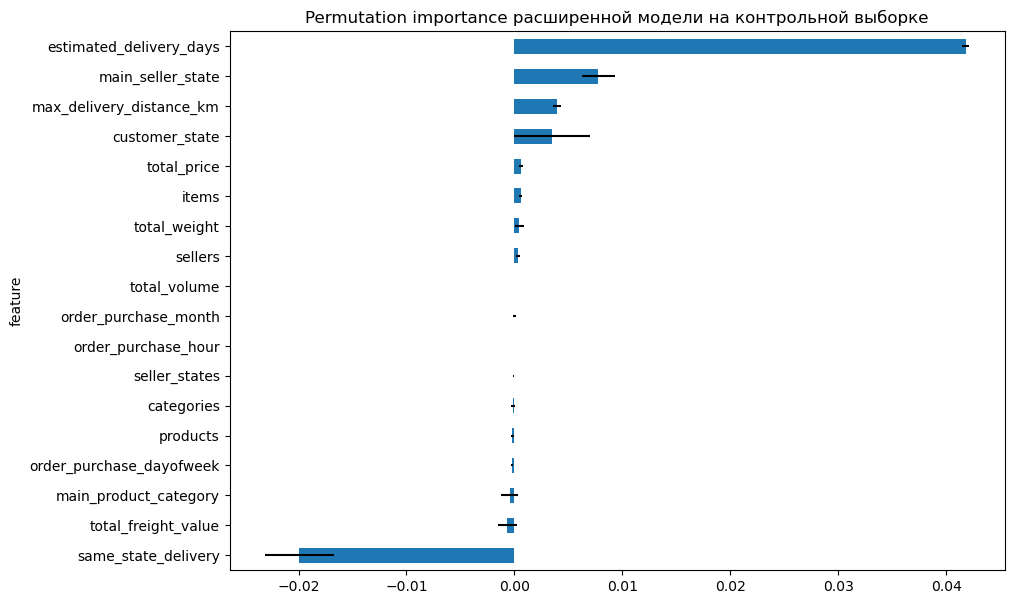

In [21]:
importance_plot_data = (
    feature_importance
    .sort_values('importance_mean')
)

importance_plot_data.plot(
    kind='barh',
    x='feature',
    y='importance_mean',
    xerr='importance_std',
    figsize=(10, 7),
    legend=False,
    title=(
        'Permutation importance расширенной модели '
        'на контрольной выборке'
    )
)

## Итоги моделирования

Добавление расстояния доставки, основного штата продавца, основной категории товара и признака совпадения штатов повысило средний PR-AUC логистической регрессии на временной кросс-валидации с `0,150` до `0,163`. Улучшение наблюдалось на четырёх из пяти временных фолдов, а относительный прирост составил около `8,5%`.

`HistGradientBoostingClassifier` не смог лучше использовать расширенный набор: его средний PR-AUC составил `0,140` против `0,163` у логистической регрессии. Поэтому дальнейшая настройка проводилась только для расширенной логистической регрессии.

Подбор параметров увеличил её средний PR-AUC до `0,166`. Лучшей оказалась модель с `L1`-регуляризацией, `C = 0,1` и без дополнительного взвешивания классов.

На отложенной контрольной выборке преимущество расширенного набора не подтвердилось. Исходная логистическая регрессия показала PR-AUC около `0,076`, а настроенная расширенная модель — около `0,075`. ROC-AUC расширенной модели оказался немного выше, однако основной метрикой проекта выбран PR-AUC, поэтому итоговым вариантом остаётся исходная логистическая регрессия.

При интерпретации результатов необходимо учитывать различие между обучающим и контрольным периодами. Доля задержек снизилась с `7,6%` в обучающей выборке до `3,5%` в контрольной. Поскольку базовый уровень PR-AUC равен доле положительного класса, более редкие задержки приводят к снижению абсолютного значения этой метрики. Поэтому PR-AUC на кросс-валидации и на контрольной выборке нельзя сравнивать напрямую без учёта распространённости задержек. На контрольном периоде обе модели более чем в два раза превосходят случайный базовый уровень, а ROC-AUC около `0,70` указывает на сохранение умеренной способности ранжировать заказы по риску задержки.

При этом изменение доли задержек не объясняет, почему расширенная модель немного уступила исходной на одной и той же контрольной выборке. Permutation importance показал, что главным источником сигнала остаётся обещанный срок доставки. Среди новых признаков полезными оказались основной штат продавца и максимальное расстояние доставки, тогда как основная категория товара почти не повлияла на результат, а признак совпадения штатов показал отрицательную важность. Вероятно, часть географической информации дублирует уже имеющиеся признаки, а её связь с задержками недостаточно устойчива во времени.

Ограниченное качество модели также может быть связано с отсутствием оперативной информации, непосредственно влияющей на доставку: текущей загрузки продавцов и логистических центров, данных о перевозчике, погодных условий, праздничных периодов и ситуации на маршруте. Кроме того, обещанный срок доставки уже косвенно учитывает часть этих факторов, поэтому другим доступным в момент оформления заказа признакам сложно дать большой дополнительный прирост.

Таким образом, дополнительные признаки улучшили результат внутри обучающего периода, но не обеспечили устойчивого преимущества на более поздних данных. С учётом основной метрики и результатов контрольной проверки исходная логистическая регрессия выбрана в качестве итоговой модели.
